# Feature ↔ Target Exploration — Rice Price Volatility

This notebook checks **which features actually relate to `target_volatility`** (and to `log_return`,
the return series it's built from) before you commit to a model. It picks up from
`Preprocessed_data/processed_full_features.csv` (via `Data_Preprocessing/paths.py`) produced by the preprocessing notebook.

Sections:
1. Load + target overview
2. Correlation of every feature with the target (linear)
3. Non-linear relevance: mutual information
4. Rolling correlation over time (does the relationship hold throughout the series, or only in some periods?)
5. Scatter plots for the top features
6. Multicollinearity check among features (VIF)
7. Model-based feature importance (Random Forest) as a cross-check against the linear correlation ranking


## 1. Load

In [3]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

PREPROC_DIR = (Path.cwd() / "Data_Preprocessing").resolve()
if str(PREPROC_DIR) not in sys.path:
    sys.path.insert(0, str(PREPROC_DIR))

from Data_Preprocessing.paths import PREPROCESSED_PATHS

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (11, 4)
sns.set_style("whitegrid")

DATA_PATH = PREPROCESSED_PATHS["processed_full_features"]
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
TARGET = "target_volatility"
print(f"Loaded: {DATA_PATH}")
print(df.shape)
df[[TARGET, "log_return", "log_price"]].describe()


Loaded: C:\Yoosuf\Sabra\Semester IV\Capstone Project in Data Science II\Final Project\Preprocessed_data\processed_full_features.csv
(571, 79)


,target_volatility,log_return,log_price
count,567.000000,570.000000,571.000000
mean,0.021187,0.001741,4.907112
std,0.038455,0.041885,0.432551
min,0.000000,-0.288092,4.300274
25%,0.004615,-0.005685,4.536570
50%,0.008986,0.000000,4.657644
75%,0.017910,0.006974,5.394654
max,0.331213,0.400243,5.564520


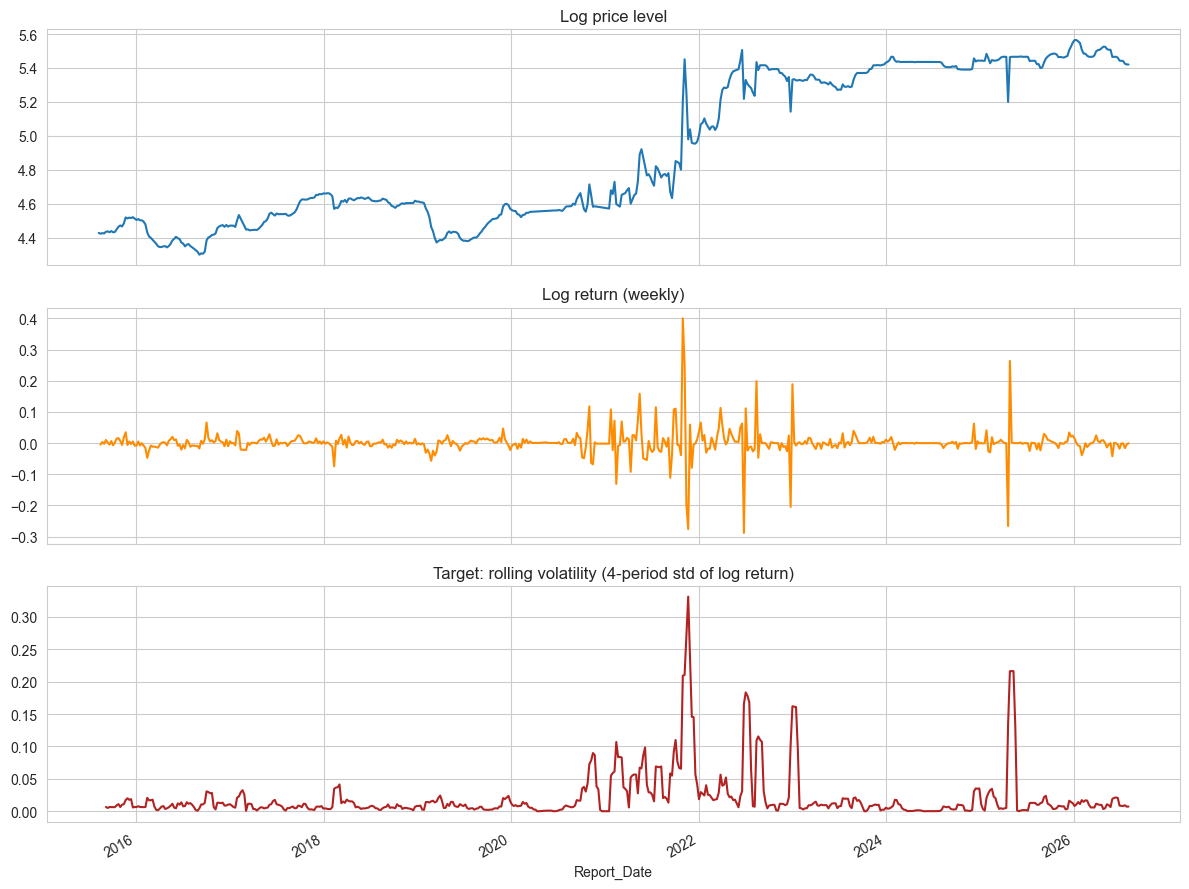

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
df["log_price"].plot(ax=axes[0], title="Log price level")
df["log_return"].plot(ax=axes[1], title="Log return (weekly)", color="darkorange")
df[TARGET].plot(ax=axes[2], title="Target: rolling volatility (4-period std of log return)", color="firebrick")
plt.tight_layout()
plt.show()


## 2. Linear correlation with target

Ranks every numeric feature by absolute Pearson correlation with `target_volatility`.
Lag/derived columns of the target itself (`log_return`, `volatility_8p`, etc.) are excluded here since
they're mechanically related — the point of this table is to see which **external drivers** matter.


In [5]:
exclude_self = ["target_volatility", "volatility_4p", "volatility_8p", "volatility_12p",
                "log_return", "log_price", "log_return_lag1", "log_return_lag2", "log_return_lag4",
                "log_price_lag1", "log_price_lag2", "log_price_lag4"]

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c not in exclude_self]

corrs = df[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
corr_table = corrs.to_frame("pearson_corr_with_target")
corr_table


,pearson_corr_with_target
season_2021Yala,0.409271
Raw red,0.278968
season_2021-2022Maha,0.217418
Raw White,0.204095
season_2020-2021Maha,0.149656
National_Yield_Efficiency,-0.140078
Kurunegala_Rice (long grain),0.137703
Anuradhapura_Rice (long grain),0.135031
Colombo City_Rice (long grain),0.130202
Samba 1,0.114154


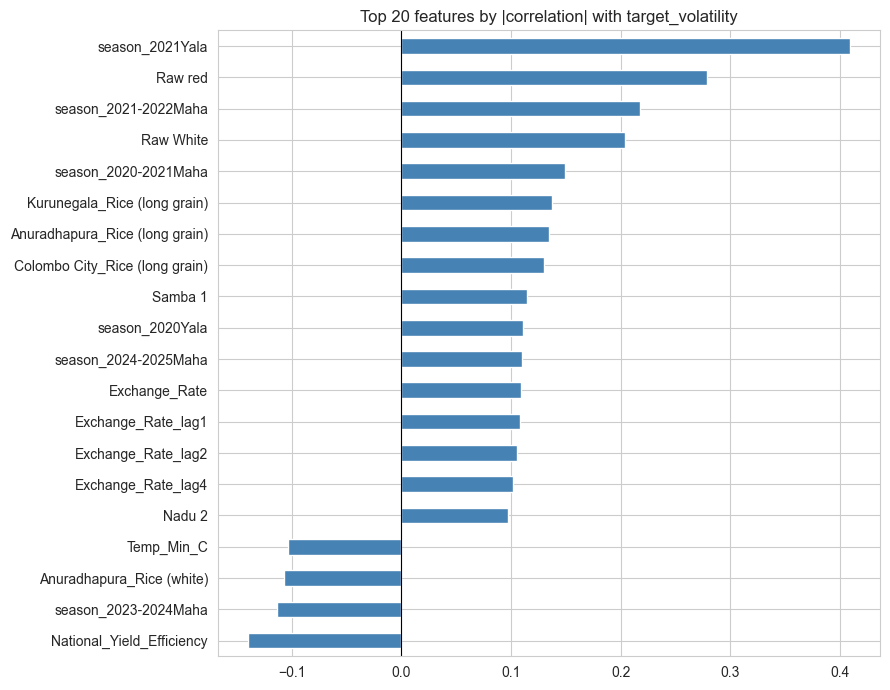

In [4]:
top_n = 20
fig, ax = plt.subplots(figsize=(9, 7))
corr_table.head(top_n)["pearson_corr_with_target"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Top {top_n} features by |correlation| with target_volatility")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## 3. Non-linear relevance: Mutual Information

Correlation only captures *linear* relationships. Mutual information (MI) picks up non-linear
dependence too — useful since volatility often has threshold/regime effects (e.g. only extreme
exchange-rate moves matter).


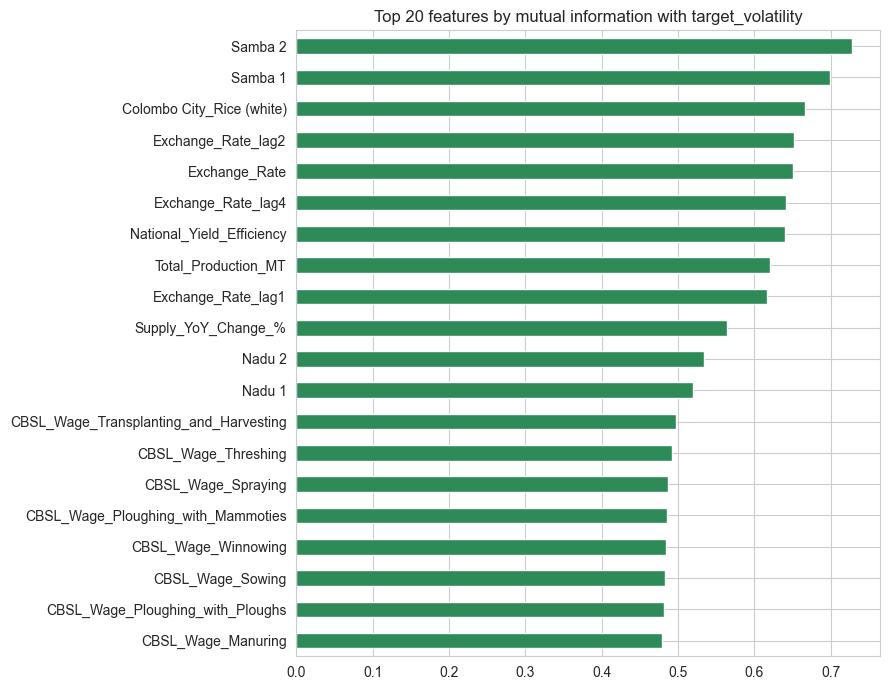

,mutual_info
Samba 2,0.728252
Samba 1,0.698662
Colombo City_Rice (white),0.666520
Exchange_Rate_lag2,0.651995
Exchange_Rate,0.650806
Exchange_Rate_lag4,0.641651
National_Yield_Efficiency,0.639641
Total_Production_MT,0.620418
Exchange_Rate_lag1,0.616388
Supply_YoY_Change_%,0.564179


In [6]:
mi_df = df[numeric_cols + [TARGET]].dropna()
mi_scores = mutual_info_regression(mi_df[numeric_cols], mi_df[TARGET], random_state=42)
mi_table = pd.Series(mi_scores, index=numeric_cols, name="mutual_info").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
mi_table.head(20).sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Top 20 features by mutual information with target_volatility")
plt.tight_layout()
plt.show()

mi_table.head(20).to_frame()


## 4. Rolling correlation over time

A feature can look correlated overall but only because of one period (e.g. the 2022 economic
crisis). This checks whether the exchange-rate / fuel relationship with volatility is *stable*
or *regime-dependent* — important for knowing whether your model will generalize.


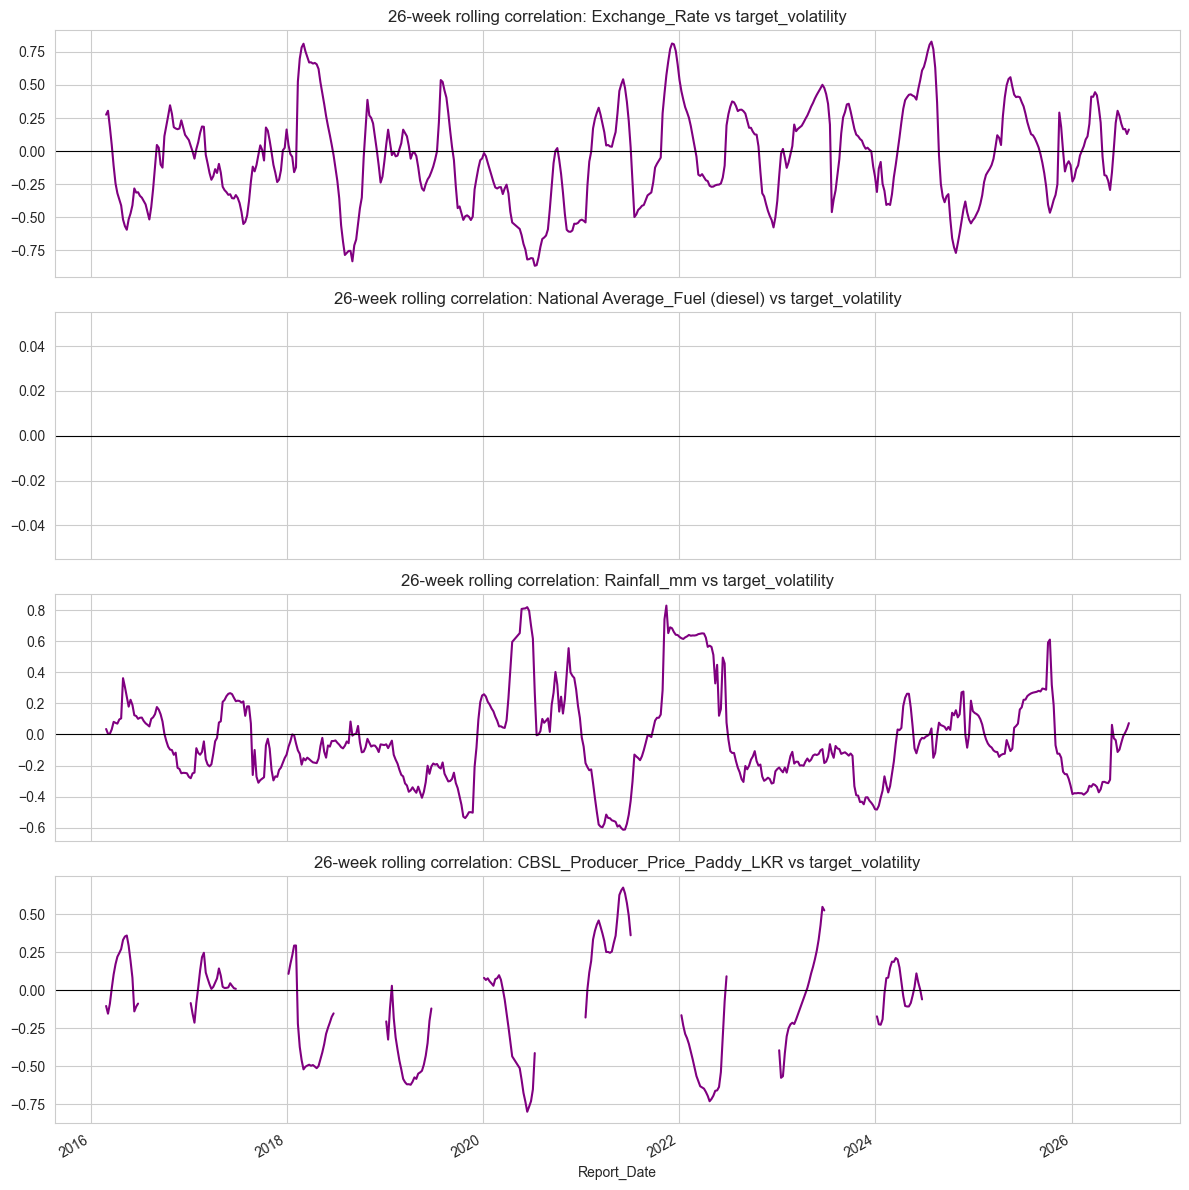

In [6]:
window = 26  # ~6 months of weekly data
check_features = [c for c in ["Exchange_Rate", "National Average_Fuel (diesel)",
                               "Rainfall_mm", "CBSL_Producer_Price_Paddy_LKR"] if c in df.columns]

fig, axes = plt.subplots(len(check_features), 1, figsize=(12, 3*len(check_features)), sharex=True)
if len(check_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, check_features):
    roll_corr = df[feat].rolling(window).corr(df[TARGET])
    roll_corr.plot(ax=ax, color="purple")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{window}-week rolling correlation: {feat} vs target_volatility")
plt.tight_layout()
plt.show()


## 5. Scatter plots — top correlated features vs target

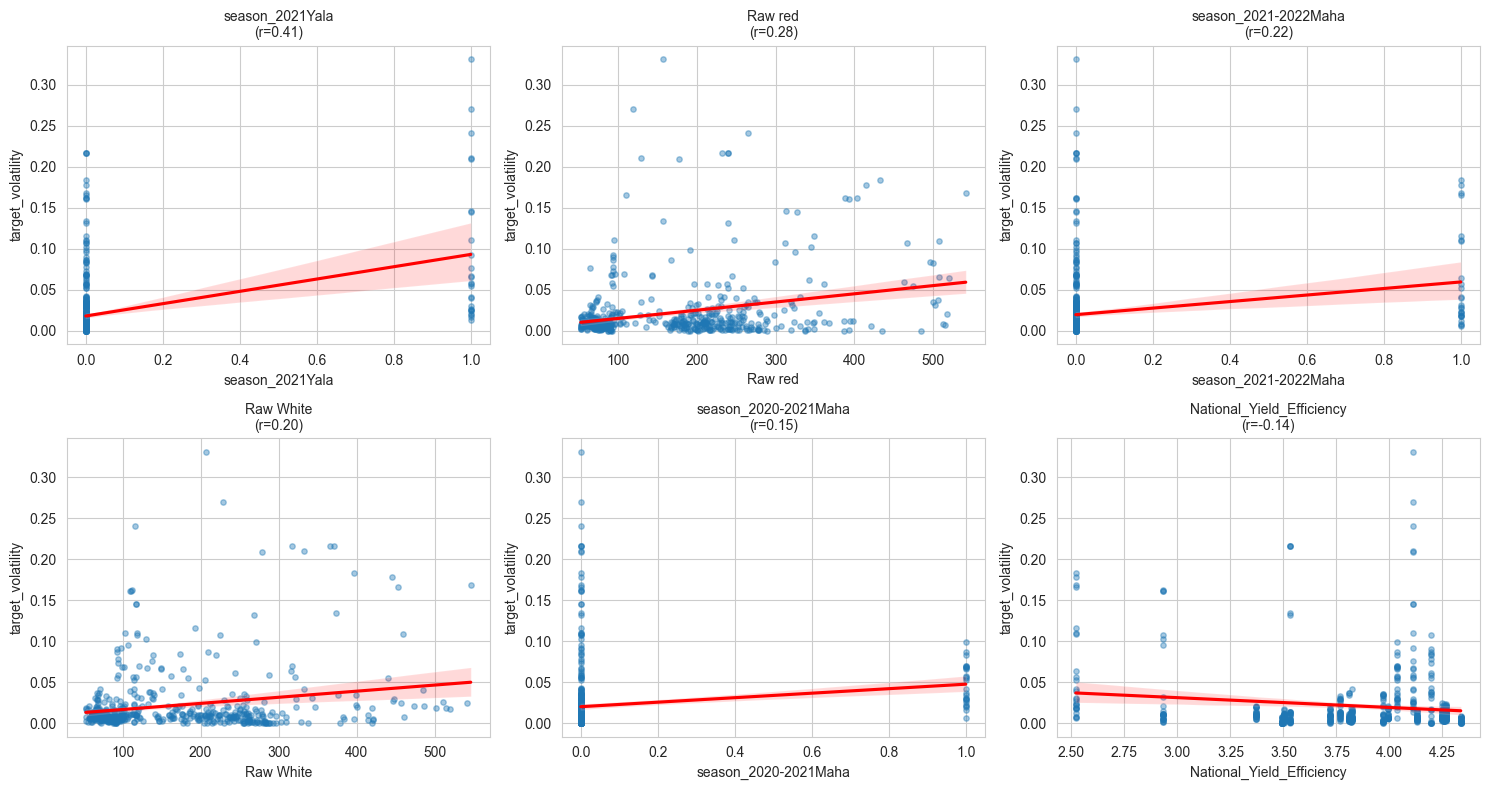

In [7]:
top_features = corr_table.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top_features):
    sns.regplot(x=df[feat], y=df[TARGET], ax=ax, scatter_kws={"alpha": 0.4, "s": 15}, line_kws={"color": "red"})
    ax.set_title(f"{feat}\n(r={corr_table.loc[feat, 'pearson_corr_with_target']:.2f})", fontsize=10)
plt.tight_layout()
plt.show()


## 6. Multicollinearity check (VIF)

If two features are highly collinear (e.g. `Exchange_Rate` and its lags, or the three retail
districts moving together), including both adds noise without adding information, and can
destabilize linear models. VIF > 10 is the usual red flag.


In [8]:
vif_features = [c for c in top_features if c in numeric_cols]
# extend with a broader candidate set, but keep it manageable
candidate_set = list(dict.fromkeys(vif_features + [c for c in numeric_cols
                     if c.startswith(("Exchange_Rate", "National Average_Fuel", "Anuradhapura", "Kurunegala", "Colombo"))]))

vif_data = df[candidate_set].dropna().astype(float)
vif_result = pd.DataFrame({
    "feature": candidate_set,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(candidate_set))]
}).sort_values("VIF", ascending=False)
vif_result


,feature,VIF
22,Exchange_Rate_lag1,14305.247872
6,Exchange_Rate,13577.266358
23,Exchange_Rate_lag2,1219.863876
24,Exchange_Rate_lag4,475.534450
13,Colombo City_Rice (white),76.008761
15,Kurunegala_Rice (medium grain),42.074636
12,Colombo City_Rice (medium grain),32.202830
19,Exchange_Rate_logret,25.243879
9,Anuradhapura_Rice (medium grain),18.655961
8,Anuradhapura_Rice (long grain),10.475867


## 7. Model-based feature importance (Random Forest)

A quick, non-linear cross-check against the correlation ranking. Random Forests handle
interactions and non-linearity, and their importances often surface features that plain
correlation misses (or discount ones correlation overrates due to collinearity).


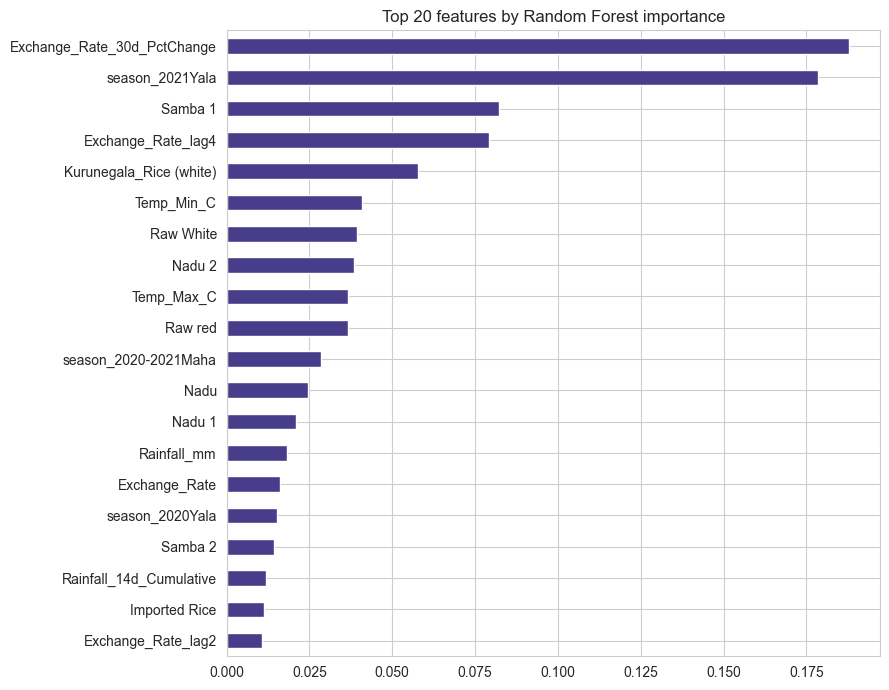

,rf_importance
Exchange_Rate_30d_PctChange,0.187849
season_2021Yala,0.178580
Samba 1,0.082318
Exchange_Rate_lag4,0.079168
Kurunegala_Rice (white),0.057666
Temp_Min_C,0.040754
Raw White,0.039377
Nadu 2,0.038350
Temp_Max_C,0.036766
Raw red,0.036709


In [9]:
rf_data = df[numeric_cols + [TARGET]].dropna()
X_rf, y_rf = rf_data[numeric_cols], rf_data[TARGET]

rf = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)

rf_importance = pd.Series(rf.feature_importances_, index=numeric_cols, name="rf_importance").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
rf_importance.head(20).sort_values().plot(kind="barh", ax=ax, color="darkslateblue")
ax.set_title("Top 20 features by Random Forest importance")
plt.tight_layout()
plt.show()

rf_importance.head(20).to_frame()


## 8. Side-by-side ranking comparison

In [10]:
comparison = pd.DataFrame({
    "abs_pearson": corrs.abs(),
    "mutual_info": mi_table,
    "rf_importance": rf_importance
}).sort_values("rf_importance", ascending=False)

comparison.head(20)


,abs_pearson,mutual_info,rf_importance
Exchange_Rate_30d_PctChange,0.053825,0.123376,0.187849
season_2021Yala,0.409271,0.070921,0.178580
Samba 1,0.114154,0.698662,0.082318
Exchange_Rate_lag4,0.102196,0.641651,0.079168
Kurunegala_Rice (white),0.083531,0.291478,0.057666
Temp_Min_C,0.103801,0.002108,0.040754
Raw White,0.204095,0.280459,0.039377
Nadu 2,0.097661,0.534280,0.038350
Temp_Max_C,0.093831,0.089866,0.036766
Raw red,0.278968,0.233769,0.036709


### How to read this
- **Consistent across all three columns** → strong, robust candidate feature — keep with confidence.
- **High correlation but low RF importance / MI** → likely collinear with something else, or the
  linear relationship is driven by a short period (check the rolling-correlation plot for that feature).
- **Low correlation but high RF importance** → non-linear/threshold effect — worth keeping even
  though it wouldn't show up in a simple correlation screen.
- Cross-check any feature you plan to drop against the VIF table too — a feature can look
  unimportant on its own purely because it's redundant with another retained feature.
